In [34]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/arpanasinghrajput/advertising-data/Advertising.csv")
df.head()


,obs,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [35]:
type(df)


pandas.core.frame.DataFrame

In [36]:
df.shape
df.columns


Index(['obs', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   obs        200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [38]:
df.describe()


,obs,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [39]:
df.isnull().sum()


obs          0
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [40]:
df.duplicated().sum()


np.int64(0)

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


Text(0.5, 1.0, 'TV advertis Vs SALES')

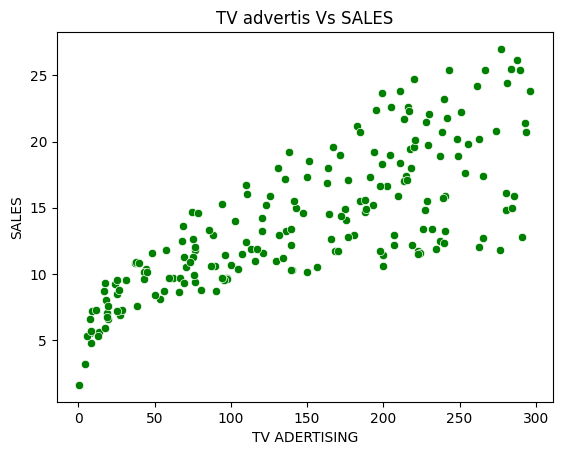

In [42]:
plt.xlabel("TV ADERTISING")
plt.ylabel("SALES")
sns.scatterplot(x='TV',y='Sales',color='green',data=df)
plt.title("TV advertis Vs SALES")


<function matplotlib.pyplot.show(close=None, block=None)>

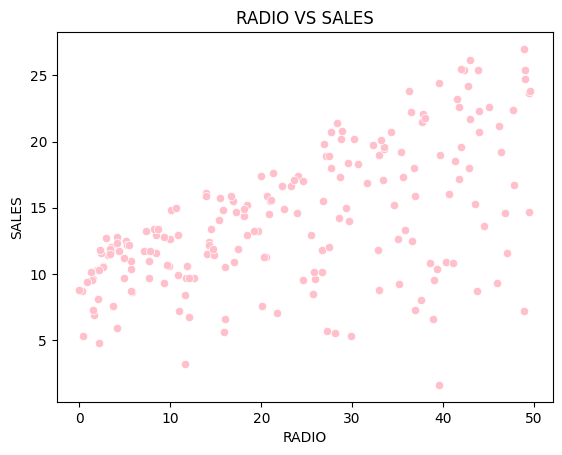

In [43]:
import matplotlib.pyplot as plt
sns.scatterplot(x="Radio",y="Sales",color="pink",data=df)
plt.xlabel("RADIO")
plt.ylabel("SALES")
plt.title('RADIO VS SALES')
plt.show


Text(0.5, 1.0, 'Newspaper VS Sales')

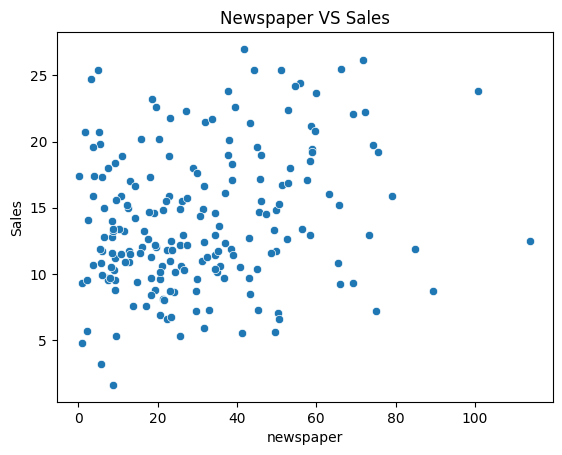

In [44]:
sns.scatterplot(x="Newspaper",y="Sales",data=df)
plt.xlabel("newspaper")
plt.ylabel("Sales")
plt.title("Newspaper VS Sales")


In [45]:
df.corr()


,obs,TV,Radio,Newspaper,Sales
obs,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


Text(0.5, 1.0, 'CORRELATION HEATMAP')

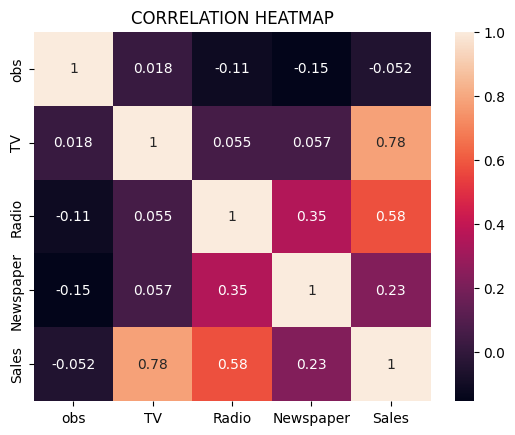

In [46]:
sns.heatmap(df.corr(),annot=True)
plt.title("CORRELATION HEATMAP")


In [47]:
df=df.drop("obs",axis=1)


In [48]:
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [49]:
X=df.drop("Sales",axis=1)
X ###INPUT VARIABLE


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [50]:
y=df["Sales"]
y ###TARGATED VALUE


0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [51]:
####SPILT THE DATA NOW
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape


(160, 3)

In [52]:
X_test.shape


(40, 3)

In [53]:
##IMPORTING LINEAR REGESSION
from sklearn.linear_model import LinearRegression
model=LinearRegression()    ##Create model
model.fit(X_train,y_train)


LinearRegression()

In [54]:
model.coef_   ##Radio ads strongly affect sales.TV ads also positively affect sales.


array([0.04472952, 0.18919505, 0.00276111])

In [55]:
model.intercept_


np.float64(2.979067338122629)

In [56]:
y_pre=model.predict(X_test)
y_pre


array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [57]:
com=pd.DataFrame({
    "Actual":y_test,"Predicted":y_pre})
com.head()


,Actual,Predicted
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373


In [58]:
##Importing R2
from sklearn.metrics import r2_score
r2_score(y_test,y_pre)


0.899438024100912

In [59]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,y_pre)
mae  ###predictions are off by about  1.46  sales units


1.4607567168117603

In [60]:
mse=mean_squared_error(y_test,y_pre)
mse


3.1740973539761033

In [61]:
import numpy as np
rmse=np.sqrt(mse)
rmse   ####Model predictions are typically off by around: 1.7 sales units


np.float64(1.78159966153345)

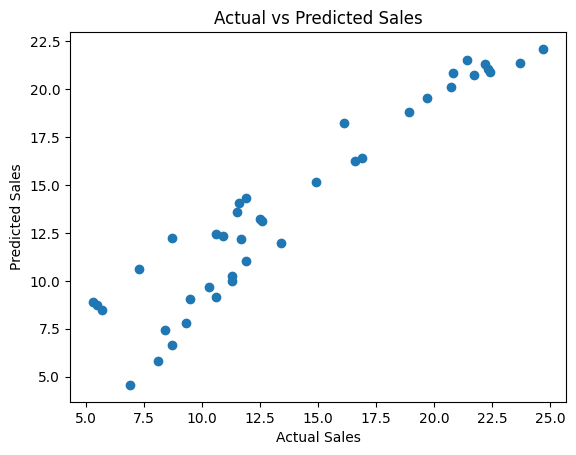

In [62]:
plt.scatter(y_test, y_pre)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()


In [63]:
res=y_test-y_pre
res


95     0.491976
15     1.510118
30    -0.153843
158   -3.308503
128    2.587627
115   -0.505592
69     1.242808
170    0.938990
174   -2.106346
45    -0.255070
66     0.451680
182    2.046717
165   -2.445545
78    -3.603493
186    0.610410
177   -0.464944
56    -3.236284
152    0.334927
82     1.022404
68     0.068909
124    0.139633
16    -0.751035
148   -1.436207
93     0.893049
65     1.472597
60     2.290426
84     0.942468
67     1.418619
125    1.416504
132   -2.806699
9     -1.866468
18     1.296623
55     2.312329
75    -3.549664
150   -2.166615
104    0.562337
135   -2.455140
137   -0.054112
164    0.882556
76     2.331004
Name: Sales, dtype: float64

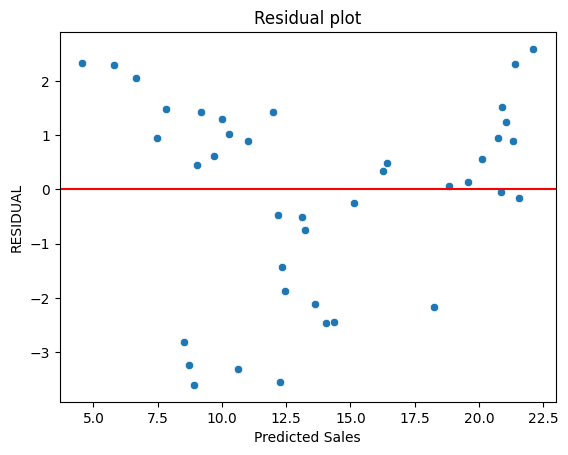

In [64]:
sns.scatterplot(x=y_pre,y=res)
plt.axhline(y=0,color='red')
plt.ylabel("RESIDUAL")
plt.xlabel("Predicted Sales")
plt.title("Residual plot")
plt.show()
##Points Above Red Line ,Residual > 0  .Actual > Predicted.Model predicted too low. 

##Points Below Red Line ,Residual < 0.Predicted > Actual,Model predicted too high.
##


<Axes: xlabel='TV', ylabel='Sales'>

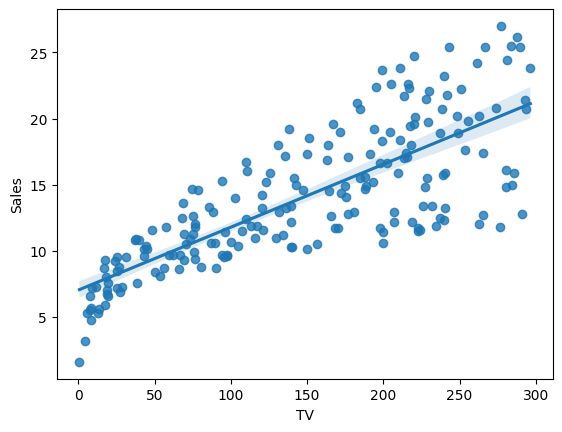

In [65]:
sns.regplot(x="TV",y="Sales",data=df)
